Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
CV Average Accuracy: 82.20%

📊 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        82
           1       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184

----------------------------------------
Overall Recall:    87.25%
Overall Precision: 82.41%
Overall F1-Score:  84.76%


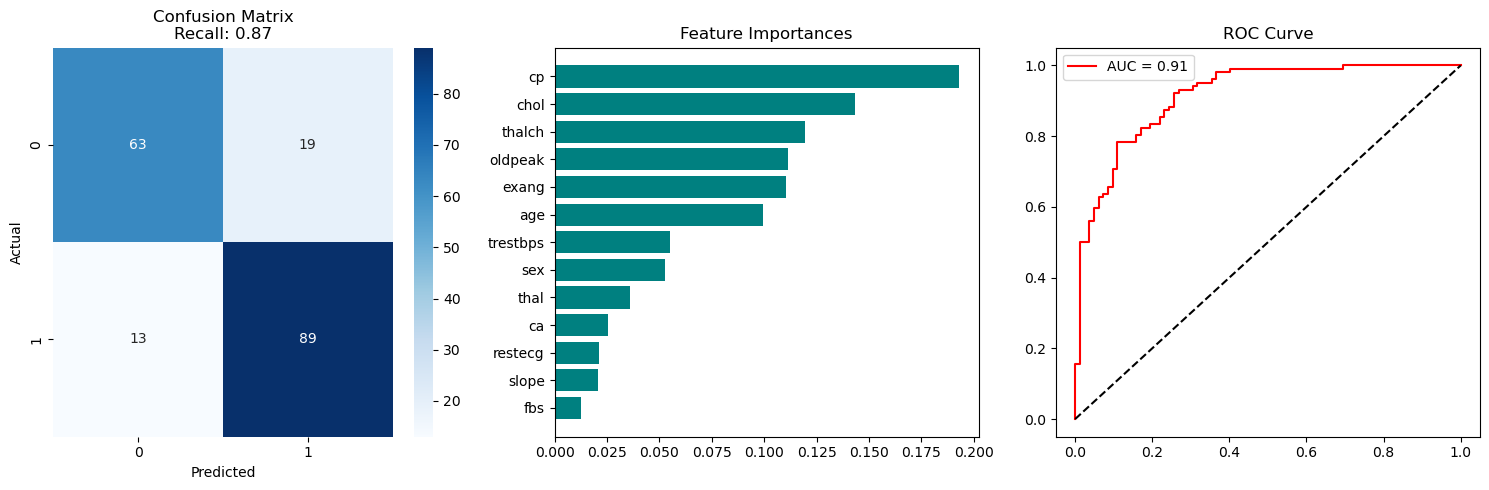


✅ All optimized files and metrics report generated successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, recall_score, precision_score, f1_score
import joblib

# 1. تحميل الداتا ومعالجتها
file_path = r'C:\Users\mf\Desktop\Intellij_work-space\Spring\AI-Driven_HeartDiseasePredictionSystem\PredictionAPI\data\heart_disease_uci.csv'
df = pd.read_csv(file_path)
df = df.drop(['id', 'dataset'], axis=1)

# معالجة القيم المفقودة
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
    # if df[col].dtype == 'object':
    #     df[col] = df[col].fillna(df[col].mode()[0])
    # else:
    #     df[col] = df[col].fillna(df[col].median())

# تحويل النصوص لأرقام
encoders = {}
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
X = df.drop(['target', 'num'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. تحسين الموديل باستخدام GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)
# لاحظ هنا خلينا الـ scoring='recall' عشان نحسن دقة اكتشاف المصابين
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1, scoring='recall')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")

# 3. الـ Cross-Validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5)
print(f"CV Average Accuracy: {np.mean(cv_scores)*100:.2f}%")

# --- الجزء الجديد: حساب وعرض المقاييس ---
y_pred = best_model.predict(X_test_scaled)

print("\n" + "="*40)
print("📊 DETAILED CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred))
print("-" * 40)
print(f"Overall Recall:    {recall_score(y_test, y_pred)*100:.2f}%")
print(f"Overall Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Overall F1-Score:  {f1_score(y_test, y_pred)*100:.2f}%")
print("=" * 40)

# 4. الرسوم التوضيحية
plt.figure(figsize=(15, 5))

# أ. مصفوفة الارتباك (Confusion Matrix)
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix\nRecall: {recall_score(y_test, y_pred):.2f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# ب. أهمية المميزات (Feature Importance)
plt.subplot(1, 3, 2)
importances = best_model.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Feature Importances')

# ج. منحنى الـ ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

# 5. الحفظ النهائي
joblib.dump(best_model, 'heart_disease_best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'label_encoders.pkl')

print("\n✅ All optimized files and metrics report generated successfully!")